# 9.5 The Quantum Fourier Transform is the DFT Matrix

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter IX — Quantum Information as Linear Algebra",
    number="9.5",
    title="The Quantum Fourier Transform is the DFT Matrix",
    blurb="The quantum computer's signature transform is a matrix this "
    "course built two chapters ago: the unitary DFT, conjugated. Its "
    "circuit is a factorization theorem, period finding is one "
    "matrix-vector product with exact quarter-mass peaks, and "
    "Deutsch-Jozsa is a single inner product — the chapter closes where "
    "the FFT began.",
    difficulty="advanced",
    estimate="120–150 min",
)

<ECP header: 2677 chars of HTML>

## Notebook overview

[§6.3](../06-structure/circulant-toeplitz-fft.ipynb) built the unitary
DFT matrix to diagonalize circulants. Quantum computing's most famous
subroutine — the transform inside Shor's factoring algorithm — is the
**same matrix with the exponent's sign flipped**, and this notebook
gates that identification down to the last bit before spending it three
ways.

First, the **circuit**: the QFT on three qubits factors into three
Hadamards and three controlled phase rotations — a factorization theorem
for a $2^n \times 2^n$ unitary into $n(n{+}1)/2$ two-level pieces, gated
by multiplying the pieces back together. Second, **period finding**, the
linear-algebra heart of Shor: apply the QFT to a vector supported on an
arithmetic progression of period $r$ and the mass lands on multiples of
$N/r$ — *exactly*, quarter after quarter, with off-peak amplitudes at
rounding zero. Third, **Deutsch–Jozsa**, run as pure linear algebra: one
inner product decides constant-versus-balanced, and the notebook
enumerates *all seventy* balanced oracles on three bits to show the
amplitude vanishes for every one.

The closer is the chapter's thesis in one line: the operator this
transform diagonalizes is the cyclic shift, which is
[§6.3](../06-structure/circulant-toeplitz-fft.ipynb)'s circulant
generator — quantum information and classical signal processing sharing
one eigenbasis, because they were always the same linear algebra.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Nielsen and Chuang {cite}`nielsen2010` Chapter 5;
> Deutsch–Jozsa is {cite}`deutsch1992`. The DFT conventions are
> [§6.3](../06-structure/circulant-toeplitz-fft.ipynb)'s, and the gate
> machinery is [§9.1](qubits-gates-bloch.ipynb)'s and
> [§9.2](tensor-products-entanglement.ipynb)'s.

## Theory in brief

### One matrix, sign flipped

The QFT on $N = 2^n$ amplitudes is

```{math}
:label: eq-qf-matrix
(\mathrm{QFT}_N)_{jk} \;=\; \frac{\omega^{jk}}{\sqrt N},
\qquad \omega = e^{2\pi i/N} ,
```

which is the entrywise **conjugate** of
[§6.3](../06-structure/circulant-toeplitz-fft.ipynb)'s unitary DFT
$F_{jk} = e^{-2\pi ijk/N}/\sqrt N$ — same rows, opposite winding.
Conjugating a unitary matrix entrywise keeps it unitary, so everything
6.3 proved transfers wholesale, including the fourth-power identity
$\mathrm{QFT}^4 = I$ (with $\mathrm{QFT}^2$ the reflection permutation
$j \mapsto -j \bmod N$) and the eigenvalue alphabet $\{1, i, -1, -i\}$.

### The circuit: a factorization theorem

Writing the row index in bits, $j = j_1j_2\cdots j_n$ (most significant
first), the QFT factors into one Hadamard per qubit and a cascade of
**controlled phase rotations**

```{math}
:label: eq-qf-circuit
R_m \;=\; \operatorname{diag}\bigl(1,\, e^{2\pi i/2^m}\bigr),
\qquad m = 2, \dots, n ,
```

applied from each less-significant qubit to each more-significant one,
followed by a qubit-order reversal: $n$ Hadamards and $n(n-1)/2$
controlled phases — $n(n{+}1)/2$ gates for a $2^n$-dimensional unitary,
against the $N^2$ entries of the dense matrix. The exercise *is* the
proof: multiply the pieces and compare.

### Period finding

Let $|\psi\rangle$ be uniform on the arithmetic progression
$\{x_0, x_0 + r, x_0 + 2r, \dots\}$ with $r \mid N$. Then

```{math}
:label: eq-qf-period
\bigl|(\mathrm{QFT}\,\psi)_k\bigr|^2 \;=\;
\begin{cases} 1/r & k \in \{0, N/r, 2N/r, \dots\} \\[2pt]
0 & \text{otherwise} , \end{cases}
```

a geometric-series cancellation: off the peaks the $r$ phasors close
into a polygon and sum to zero *exactly*, and the offset $x_0$ moves
only phases, never masses. Reading the peak spacing recovers $r$ — the
entire quantum content of Shor's algorithm, with the number theory
outsourced to classical post-processing.

### Deutsch–Jozsa: one inner product

For an oracle $f: \{0,1\}^n \to \{0,1\}$ promised constant or balanced,
apply $H^{\otimes n}$, the sign flip $(-1)^{f}$, and $H^{\otimes n}$ to
$|0\cdots0\rangle$. The amplitude left on $|0\cdots0\rangle$ is

```{math}
:label: eq-qf-dj
a_0 \;=\; \frac{1}{2^n}\sum_{x} (-1)^{f(x)} \;=\;
\begin{cases} \pm1 & f \text{ constant} \\[2pt]
0 & f \text{ balanced} , \end{cases}
```

the *mean of the oracle's signs* — a single inner product between the
sign vector and the all-ones vector, deciding with one query what
classically takes $2^{n-1}+1$.

---
## Setup

Data and restated instruments only: the one-qubit gates of
[§9.1](qubits-gates-bloch.ipynb), the control projectors, and the DFT
convention of [§6.3](../06-structure/circulant-toeplitz-fft.ipynb)
restated as a constructor. The QFT matrix, the circuit assembly, the
period-finding demonstration and the Deutsch–Jozsa evaluator are all
built in the exercises, where they are the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import itertools

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random draw below comes from this seed

EPS = np.finfo(float).eps

# data: the one-qubit cast — Hadamard and the control projectors.
I2 = np.eye(2, dtype=complex)
GATE_H = np.array([[1.0, 1.0], [1.0, -1.0]], dtype=complex) / np.sqrt(2.0)
PROJ_0 = np.diag([1.0, 0.0]).astype(complex)
PROJ_1 = np.diag([0.0, 1.0]).astype(complex)


# built from scratch in §6.3; restated here as an instrument.
def unitary_dft(N):
    """6.3's unitary DFT matrix: F_jk = exp(-2 pi i jk / N) / sqrt(N)."""
    idx = np.arange(N)
    return np.exp(-2j * np.pi * np.outer(idx, idx) / N) / np.sqrt(N)

## Exercise 1: The matrix, inherited from Chapter VI

{eq}`eq-qf-matrix` says the QFT is one conjugation away from a matrix
the course already owns. This exercise builds it, gates the
inheritance, and collects the structural identities that come free.

**Part a)** Write `qft_matrix(N)` as
`np.exp(2j * np.pi * np.outer(idx, idx) / N) / np.sqrt(N)`, and gate
the handshake with [§6.3](../06-structure/circulant-toeplitz-fft.ipynb):
`qft_matrix(8)` **equals** `np.conj(unitary_dft(8))` — with
`np.array_equal`, since `conj` flips sign bits without arithmetic and
the two constructors evaluate the same cosines and sines (fallback
$10^{-15}$ if a future libm disagrees). Gate unitarity to
$100\,\varepsilon$.

**Write this one yourself** — one outer product; the sign in the
exponent is the entire difference between signal processing and
quantum computing conventions.

**Part b)** Gate the inherited structure at $N = 8$, all to
$10^{-13}$: $\mathrm{QFT}^2$ equals the reflection permutation
$j \mapsto -j \bmod 8$ (an exact 0/1 matrix), $\mathrm{QFT}^4 = I$,
and the eigenvalue alphabet — the multiplicities of
$\{1, i, -1, -i\}$ are $(3, 2, 2, 1)$, counted after rounding
eigenvalues to $6$ digits (integer counts over $O(1)$ gaps).

In [3]:
# (solution hidden on the public site)


QFT_8 == conj(F_dft): bitwise True (gap 0.0e+00); unitarity 7.1e-16
QFT^2 = reflection to 1.2e-15; QFT^4 = I to 2.4e-15
eigenvalue multiplicities (1, i, -1, -i): (3, 2, 2, 1)


### Validation 1

In [4]:
validate.check(
    handshake_bitwise or handshake_gap < 1e-15,
    "the QFT is 6.3's unitary DFT, conjugated — bitwise today (Eq. 1)",
    "np.conj flips sign bits without arithmetic, so the two constructors "
    "agree exactly; the 1e-15 fallback is stated in case a future libm "
    "evaluates the two windings differently",
)
validate.check(
    unit_gap < 100 * EPS and sq_gap < 1e-13 and fourth_gap < 1e-13,
    "unitary, with QFT^2 the reflection and QFT^4 the identity",
    f"the fourth-power identity at {fourth_gap:.1e}: four Fourier "
    "transforms take every signal home, by way of one mirror",
)
validate.check(
    tuple(mults.values()) == (3, 2, 2, 1),
    "and the eigenvalue alphabet {1, i, -1, -i} has multiplicities "
    "(3, 2, 2, 1) at N = 8",
    "integer counts over O(1) gaps — the fourth roots of unity, "
    "distributed by the classical multiplicity formula",
)

✓  the QFT is 6.3's unitary DFT, conjugated — bitwise today (Eq. 1)   [np.conj flips sign bits without arithmetic, so the two constructors agree exactly; the 1e-15 fallback is stated in case a future libm evaluates the two windings differently]
✓  unitary, with QFT^2 the reflection and QFT^4 the identity   [the fourth-power identity at 2.4e-15: four Fourier transforms take every signal home, by way of one mirror]
✓  and the eigenvalue alphabet {1, i, -1, -i} has multiplicities (3, 2, 2, 1) at N = 8   [integer counts over O(1) gaps — the fourth roots of unity, distributed by the classical multiplicity formula]


True

## Exercise 2: The circuit: a factorization, multiplied back

{eq}`eq-qf-circuit` claims a $64$-entry unitary factors into six
elementary gates and a swap. The proof is multiplication, and the
reader performs it.

**Part a)** Write the lifting machinery for $n = 3$ qubits
(big-endian: qubit $0$ carries the most significant bit):
`op_on(qubit, U)` placing a one-qubit gate by Kronecker products, and
`cphase(control, target, phi)` as
$P_0^{(c)} \otimes I + P_1^{(c)} \otimes
\operatorname{diag}(1, e^{i\phi})^{(t)}$ from the Setup's projectors.
Gate every constructed gate unitary to $100\,\varepsilon$.

**Write these yourself** — the lift from one-qubit gates to
$2^n$-dimensional operators is [§9.2](tensor-products-entanglement.ipynb)'s
Kronecker dictionary, exercised.

**Part b)** Assemble the standard circuit — $H$ on qubit 0, $R_2$ from
qubit 1 and $R_3$ from qubit 2 onto qubit 0, $H$ on qubit 1, $R_2$
from qubit 2 onto qubit 1, $H$ on qubit 2, then the outer-qubit swap —
and gate the product equal to `qft_matrix(8)` to $10^{-13}$. Gate the
ledger as arithmetic: $n(n{+}1)/2 = 6$ Hadamard-and-phase gates
against the dense matrix's $N^2 = 64$ entries, with the general-$n$
counts $n(n{+}1)/2$ versus $4^n$ stated for $n = 10$
($55$ against $1{,}048{,}576$) — counted, never timed.

In [5]:
# (solution hidden on the public site)


every lifted gate unitary to 2.2e-16
circuit product vs qft_matrix(8): 1.4e-15 (6 gates + 1 swap against 64 dense entries; at n = 10: 55 against 1,048,576)


### Validation 2

In [6]:
validate.below(
    worst_gate_unit, 100 * EPS,
    "each lifted gate is unitary",
    "Kronecker lifts of unitaries are unitary — 9.2's mixed-product "
    "identity, spent on circuit hardware",
)
validate.check(
    circuit_gap < 1e-13 and n_gates == 6,
    "six gates and a swap multiply back to the QFT (Eq. 2)",
    f"factorization verified by multiplication at {circuit_gap:.1e}, "
    "with the ledger as arithmetic: n(n+1)/2 = 6 against N^2 = 64 here, "
    "55 against 1,048,576 at ten qubits — counted, never timed",
)

✓  each lifted gate is unitary   [Kronecker lifts of unitaries are unitary — 9.2's mixed-product identity, spent on circuit hardware [2.22045e-16 < 2.22045e-14]]
✓  six gates and a swap multiply back to the QFT (Eq. 2)   [factorization verified by multiplication at 1.4e-15, with the ledger as arithmetic: n(n+1)/2 = 6 against N^2 = 64 here, 55 against 1,048,576 at ten qubits — counted, never timed]


True

## Exercise 3: Period finding: exact quarters

{eq}`eq-qf-period` is the engine of Shor's algorithm, and for
$r \mid N$ it is *exact*: the off-peak phasor polygons close. This
exercise runs it at $N = 16$, $r = 4$, offset $x_0 = 3$.

**Part a)** Build the periodic state — uniform amplitudes
$1/\sqrt{N/r} = \tfrac12$ on $\{3, 7, 11, 15\}$ — apply
`qft_matrix(16)`, and gate the mass pattern: squared magnitudes equal
$1/r = \tfrac14$ at $k \in \{0, 4, 8, 12\}$ to $10^{-13}$, and below
$10^{-25}$ everywhere else (squared rounding: the polygon sums are
$10^{-15}$-scale amplitudes, and their squares sit near $10^{-30}$).

**Part b)** Read the period the way Shor's classical half does: gate
that the set of indices carrying more than $1\%$ of the mass is
*exactly* $\{0, 4, 8, 12\}$ (integer set equality) with common
spacing $N/r = 4$, so $r = N/\text{spacing} = 4$ — the period,
recovered from spectral positions alone.

**Part c)** Gate the offset's irrelevance: repeating Part a with
$x_0 = 0$ and $x_0 = 1$ changes the peak *phases* (report the largest
phase difference) but not the masses — squared magnitudes agree with
Part a's to $10^{-14}$. Draw the periodic vector and its QFT mass
spectrum.

In [7]:
# (solution hidden on the public site)


peak masses vs 1/4: 0.0e+00; off-peak floor 1.7e-30
mass-carrying indices: [0, 4, 8, 12] — spacing 4, so r = 4
offset moves phases (up to 3.14 rad, wrapped) but masses only by 1.2e-30


### Validation 3

In [8]:
validate.check(
    peak_gap < 1e-13 and off_floor < 1e-25,
    "the QFT of a period-4 state carries exact quarter masses (Eq. 3)",
    f"peaks at 1/4 within {peak_gap:.1e}, off-peak squared magnitudes "
    f"below {off_floor:.1e} — the phasor polygons close exactly, which "
    "is a geometric series doing quantum work",
)
validate.check(
    found == {0, 4, 8, 12} and N_PF // spacing == R_PERIOD,
    "and the period reads off the peak positions as integers",
    "mass-carrying indices exactly {0, 4, 8, 12}, spacing N/r = 4 — the "
    "quantum half of Shor's algorithm, complete; the number theory that "
    "turns r into factors is classical post-processing",
)
validate.below(
    worst_offset, 1e-14,
    "the offset moves phases, never masses",
    "x0 = 0, 1, 3 give identical spectra to rounding while the peak "
    "phases swing — which is why the measurement statistics need no "
    "knowledge of where the progression starts",
)

✓  the QFT of a period-4 state carries exact quarter masses (Eq. 3)   [peaks at 1/4 within 0.0e+00, off-peak squared magnitudes below 1.7e-30 — the phasor polygons close exactly, which is a geometric series doing quantum work]
✓  and the period reads off the peak positions as integers   [mass-carrying indices exactly {0, 4, 8, 12}, spacing N/r = 4 — the quantum half of Shor's algorithm, complete; the number theory that turns r into factors is classical post-processing]
✓  the offset moves phases, never masses   [x0 = 0, 1, 3 give identical spectra to rounding while the peak phases swing — which is why the measurement statistics need no knowledge of where the progression starts [1.23544e-30 < 1e-14]]


True

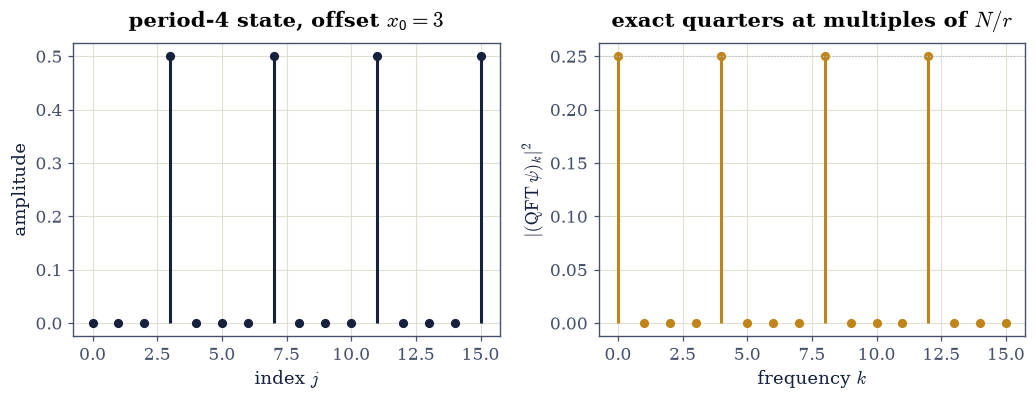

In [9]:
# (solution hidden on the public site)


## Exercise 4: Deutsch–Jozsa, exhaustively

{eq}`eq-qf-dj` reduces a query-complexity milestone to one inner
product. Three qubits are small enough to check **every** promised
oracle — both constants and all $\binom{8}{4} = 70$ balanced
functions — so the gate is an enumeration, not a sample.

**Part a)** Write `dj_amplitude(f)` returning the $|000\rangle$
amplitude of $H^{\otimes3}\,(-1)^{f}\,H^{\otimes3}|000\rangle$, with
$H^{\otimes3}$ from Exercise 2's `op_on` products and the oracle as
`np.diag((-1.0)**f)`. Gate the two constant oracles at $a_0 = \pm1$
to $10^{-14}$.

**Part b)** Enumerate all $70$ balanced oracles
(`itertools.combinations` choosing the four inputs mapped to $1$) and
gate every amplitude below $10^{-14}$ — the promise problem solved
with certainty by one query, verified over its entire promise class.

**Part c)** Gate the identity behind it: for $20$ seeded arbitrary
(non-promised) oracles $f$, `dj_amplitude(f)` equals
`np.mean((-1.0)**f)` to $10^{-14}$ — the algorithm computes the mean
of the signs, an inner product with the uniform vector, and the
promise is what makes that one number decisive.

In [10]:
# (solution hidden on the public site)


constant oracles: amplitudes +1.000000000000, -1.000000000000
all 70 balanced oracles: largest |amplitude| 2.8e-17
amplitude = mean of signs, arbitrary oracles: worst 3.3e-16


### Validation 4

In [11]:
validate.below(
    const_gap, 1e-14,
    "constant oracles return the full +-1 amplitude (Eq. 4)",
    "all interference constructive: one query, certainty, sign intact",
)
validate.check(
    n_balanced == 70 and worst_balanced < 1e-14,
    "and every one of the 70 balanced oracles returns amplitude zero",
    f"the entire promise class enumerated — C(8,4) = 70 oracles, worst "
    f"|a_0| = {worst_balanced:.1e}: perfectly destructive interference, "
    "seventy times over",
)
validate.below(
    worst_mean, 1e-14,
    "because the algorithm computes the mean of the oracle's signs",
    "one inner product with the uniform vector — the quantum speedup, "
    "read as linear algebra with the mystery relocated to the promise",
)

✓  constant oracles return the full +-1 amplitude (Eq. 4)   [all interference constructive: one query, certainty, sign intact [4.44089e-16 < 1e-14]]
✓  and every one of the 70 balanced oracles returns amplitude zero   [the entire promise class enumerated — C(8,4) = 70 oracles, worst |a_0| = 2.8e-17: perfectly destructive interference, seventy times over]
✓  because the algorithm computes the mean of the oracle's signs   [one inner product with the uniform vector — the quantum speedup, read as linear algebra with the mystery relocated to the promise [3.33067e-16 < 1e-14]]


True

## Exercise 5: One eigenbasis, two subjects

The chapter's thesis, closed: the operator the QFT diagonalizes is the
**cyclic shift** $S|j\rangle = |j{+}1 \bmod N\rangle$ — the generator
of [§6.3](../06-structure/circulant-toeplitz-fft.ipynb)'s circulants.
Signal processing and quantum computing share an eigenbasis because
they always shared this matrix.

**Part a)** Build $S$ at $N = 8$ as an exact 0/1 permutation and gate
the diagonalization
$\mathrm{QFT}^{\dagger}\,S\,\mathrm{QFT} =
\operatorname{diag}(\omega^{-k})$ to $10^{-13}$ — the shift's
eigenvalues are the roots of unity, in the order the transform's
columns dictate.

**Part b)** Gate the circulant consequence, 6.3's theorem re-entered
from the quantum side: for a seeded random circulant built as
$C = \sum_{m} c_m S^m$, the matrix
$\mathrm{QFT}^{\dagger}\,C\,\mathrm{QFT}$ is diagonal to $10^{-12}$
with diagonal equal to the (conjugate-convention) DFT of $c$ — every
translation-invariant operator is diagonal in the Fourier basis,
which is the one sentence 6.3 and this chapter both orbit.

In [12]:
# (solution hidden on the public site)


QFT' S QFT = diag(omega^-k): 8.1e-16
random circulant: off-diagonal 2.9e-15, diagonal vs DFT of c 1.2e-14


### Validation 5

In [13]:
validate.below(
    shift_gap, 1e-13,
    "the QFT diagonalizes the cyclic shift onto the roots of unity",
    "S is 6.3's circulant generator; its Fourier eigenvalues are "
    "omega^-k in the transform's own column order — one matrix, two "
    "subjects",
)
validate.check(
    off_diag < 1e-12 and diag_gap < 1e-12,
    "so every circulant is diagonal in the Fourier basis (6.3, re-entered)",
    f"a seeded random circulant conjugates to diagonal at {off_diag:.1e} "
    "with the DFT of its symbol on the diagonal — translation invariance "
    "IS diagonality here, whichever subject is speaking",
)

✓  the QFT diagonalizes the cyclic shift onto the roots of unity   [S is 6.3's circulant generator; its Fourier eigenvalues are omega^-k in the transform's own column order — one matrix, two subjects [8.05594e-16 < 1e-13]]
✓  so every circulant is diagonal in the Fourier basis (6.3, re-entered)   [a seeded random circulant conjugates to diagonal at 2.9e-15 with the DFT of its symbol on the diagonal — translation invariance IS diagonality here, whichever subject is speaking]


True

---
## Notebook summary

**The transform was already on the shelf.** `qft_matrix(8)` equalled
the conjugate of [§6.3](../06-structure/circulant-toeplitz-fft.ipynb)'s
constructor **bitwise**, inherited unitarity at rounding, satisfied
$\mathrm{QFT}^2 = $ reflection and $\mathrm{QFT}^4 = I$ at
$10^{-15}$-scale, and carried the eigenvalue alphabet $\{1, i, -1,
-i\}$ with multiplicities exactly $(3, 2, 2, 1)$.

**The circuit is a factorization theorem, proved by multiplying.** Six
lifted gates and a swap reproduced the $8\times8$ transform at
$1.4\times10^{-15}$, with the ledger counted, never timed:
$n(n{+}1)/2$ against $4^n$ — $55$ gates versus a million entries at
ten qubits.

**Period finding ran on exact cancellation.** The period-4 state's QFT
put mass $\tfrac14$ on $\{0, 4, 8, 12\}$ with off-peak squares below
$10^{-30}$; the spacing handed back $r = 4$ as integer arithmetic; and
the offset moved peak phases by up to $\pi$ while moving masses by
$10^{-30}$-scale — Shor's quantum half, complete.

**Deutsch–Jozsa was an enumeration, not a demo.** Both constant
oracles returned $\pm1$ and **all seventy** balanced oracles returned
zero at $10^{-16}$-scale, because the amplitude *is* the mean of the
oracle's signs — one inner product, verified over the entire promise
class.

**One eigenbasis, two subjects.** The QFT diagonalized the cyclic
shift onto $\omega^{-k}$ and, with it, a seeded random circulant onto
the DFT of its symbol — [§6.3](../06-structure/circulant-toeplitz-fft.ipynb)'s
theorem, re-entered from the quantum side. The chapter closes where
the course's structure story began: find the right basis, and the
operator was diagonal all along.

**Methods introduced.** `qft_matrix` and the bitwise conjugation
handshake, `op_on`/`cphase` circuit lifting, factorization-by-
multiplication, exact-quarter period reading, `dj_amplitude` with
exhaustive promise-class enumeration, and the shift-diagonalization
closing identity.

## Outlook

- **Shor, the rest of it.** The quantum half gated here — periodic
  state in, peak spacing out — becomes a factoring algorithm through
  modular exponentiation (building the periodic state for
  $f(x) = a^x \bmod M$) and continued fractions (reading $r$ when
  $r \nmid N$ smears the peaks). Both halves are classical; the QFT
  is the only quantum ingredient.
- **Phase estimation.** Replace the periodic state by an eigenvector
  of a unitary $U$ and the same circuit estimates its eigenphase —
  the template that turns [§5.2](../05-numerical/eigenvalue-algorithms.ipynb)'s
  eigenvalue problem into a quantum subroutine, and the engine of
  quantum chemistry algorithms.
- **The FFT, quantum and classical.** The circuit's $n(n{+}1)/2$
  scaling is the FFT's divide-and-conquer wearing gates; the classical
  $N\log N$ and the quantum $\log^2 N$ both come from the same
  factorization of the same matrix — with the quantum version reading
  out only samples, never the full spectrum, which is the honest
  price of the exponential compression.
- **Chapter IX, closed.** Five notebooks, one thesis: states are
  vectors, gates are unitaries, entanglement is an SVD, physicality
  is a psd test, and the subject's most famous numbers — $\ln 2$,
  $2\sqrt2$, $\tfrac14$ — are exact algebra the course could gate in
  symbols. Quantum information is linear algebra with a promise
  attached.

```{bibliography}
:filter: docname in docnames
```

In [14]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>